## Part 3: Demonstration using the Berkeley Milling Wear Dataset

**USF INFORMS Student Chapter**  
Sponsored by the INFORMS Quality, Statistics, and Reliability (QSR) Section  
Friday, October 9, 2026 · ENG 3

Imagine you manage a factory that uses milling machines to manufacture parts. As a cutting tool is used, it wears down.

Replacing it too early wastes useful tool life. Replacing it too late can affect product quality. Measuring wear after every run also takes time and resources.

**Our question:** Can sensor measurements collected during a milling run help estimate tool wear and support decisions about when to inspect the tool?

We will build a wear estimator, check how well it works, and examine whether its predictions are useful for inspection decisions.

| Step | What we will do |
|---|---|
| 1 | Understand the experiment and load the data |
| 2 | Inspect sensors data |
| 3 | Build a basic model |
| 4 | Check what different sensor groups and richer features contribute |
| 5 | Predict a range of possible wear values and check its coverage |
| 6 | Compare inspection rules and their missed versus unnecessary inspections |

**Keep this distinction in mind:** Estimating wear is a modeling task. Choosing when to inspect or replace a tool is a decision that also depends on uncertainty, costs, and acceptable risk.


## Dataset Download

The supplied Colab cell downloads your **`mill_data.mat`** from Google Drive using `gdown`, then loads its MATLAB records.

Source: [NASA PCoE repository, Milling entry](https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/).


In [ ]:
!pip -q install gdown

import gdown
import os
from scipy.io import loadmat


FILE_ID = "1YG7EhcDnBr0_URrVetxIt21JozHpHbT-"
DATA_PATH = "mill_data.mat"

# Remove previously downloaded invalid file
if os.path.exists(DATA_PATH):
    os.remove(DATA_PATH)

# Download the actual file
gdown.download(
    id=FILE_ID,
    output=DATA_PATH,
    quiet=False
)

# Check the downloaded file
print("File size:", os.path.getsize(DATA_PATH), "bytes")

with open(DATA_PATH, "rb") as f:
    print("File header:", f.read(80))

# Load MATLAB data
raw = loadmat(
    DATA_PATH,
    squeeze_me=True,
    struct_as_record=False
)['mill'].ravel()

Downloading...
From (original): https://drive.google.com/uc?id=1YG7EhcDnBr0_URrVetxIt21JozHpHbT-
From (redirected): https://drive.google.com/uc?id=1YG7EhcDnBr0_URrVetxIt21JozHpHbT-&confirm=t&uuid=17935a89-d07d-408d-8200-8ef16b7ec49b
To: /content/mill_data.mat
100%|██████████| 72.6M/72.6M [00:00<00:00, 182MB/s]


File size: 72575144 bytes
File header: b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Tue Nov 27 15:59:45 2007      '


In [ ]:
# Import the tools we will use for tables, plots, signals, and models.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy, skew, kurtosis, norm
from sklearn.linear_model import Ridge, BayesianRidge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

CHANNELS = ['smcAC', 'smcDC', 'vib_table', 'vib_spindle', 'AE_table', 'AE_spindle']
CHANNEL_NAMES = {'smcAC': 'AC motor current', 'smcDC': 'DC motor current',
    'vib_table': 'Table vibration', 'vib_spindle': 'Spindle vibration',
    'AE_table': 'Table acoustic emission', 'AE_spindle': 'Spindle acoustic emission'}
GREEN, BLUE, GOLD = '#006747', '#007DA5', '#B58B00'
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 11

## 1. About the experiments

A milling tool removes material from a workpiece. Repeated cutting wears the insert's flank face. **VB is the width of that worn band, measured in millimetres.** Larger VB means more measured wear.

For each **case**, the material, feed, and depth of cut are fixed. Successive **runs** belong to that experimental sequence. Sensors record during cutting; a microscope measurement supplies one VB value after selected runs. Some runs have no wear measurement.

| Level | What it represents |
|---|---|
| Case | An experimental sequence at fixed conditions (1-16) |
| Run | Counter for experimental runs at each case |
| Sensor reading | One sample within a run's recorded trace |
| VB label | Flank wear, measured after runs, not all (mm) |

**About the data:** a run has 9,000 readings in each channel and one VB label. Does it provide one labeled example or 9,000 independent labeled examples?


**Connection to Part 1:** several Fitbit days belong to one person; several milling runs belong to one case. Group membership matters when we evaluate predictions.

Source: Goebel & Agogino, *Documentation for Mill Data Set*, archive `Readme.pdf`, pp. 1–3. The documentation describes fixed speed in this release: 200 m/min (826 rpm).

In [ ]:
# Create one table row per run, with its conditions and measured wear.
rows = []
for number, record in enumerate(raw, start=1):
    rows.append({
        'record': number,
        'case': int(record.case),
        'run': int(record.run),
        'VB': float(record.VB),
        'DOC': float(record.DOC),
        'feed': float(record.feed),
        'material': int(record.material)
    })

df = pd.DataFrame(rows)
df['material_name'] = df['material'].map({1: 'Cast iron', 2: 'Steel'})
print(df[['case', 'run', 'VB', 'DOC', 'feed', 'material_name']].head())
df.size


# what affects tool wear?

   case  run    VB  DOC  feed material_name
0     1    1  0.00  1.5   0.5     Cast iron
1     1    2   NaN  1.5   0.5     Cast iron
2     1    3   NaN  1.5   0.5     Cast iron
3     1    4  0.11  1.5   0.5     Cast iron
4     1    5   NaN  1.5   0.5     Cast iron


1336

There are 16 cases in total. 1-8 with unique conditions and 9-16 repeat cases. So there are two cases with same conditions.
| Material | Depth (mm) | Feed (mm/rev) | First case | Repeat case |
|---|---:|---:|---:|---:|
| Cast iron | 1.5 | 0.5 | 1 | 9 |
| Cast iron | 0.75 | 0.5 | 2 | 12 |
| Cast iron | 0.75 | 0.25 | 3 | 11 |
| Cast iron | 1.5 | 0.25 | 4 | 10 |
| Steel | 1.5 | 0.5 | 5 | 16 |
| Steel | 1.5 | 0.25 | 6 | 15 |
| Steel | 0.75 | 0.25 | 7 | 13 |
| Steel | 0.75 | 0.5 | 8 | 14 |

A missing VB (`NaN`) means no recorded wear measurement, not zero wear.

In [ ]:
# Remove the two signal records identified as corrupted
usable = df[~df['record'].isin([18, 95])].copy()

# Supervised modeling needs an observed target: do not fill missing VB.
usable = usable.dropna(subset=['VB']).reset_index(drop=True)
usable['steel'] = (usable['material'] == 2).astype(int)

print('Observed VB labels before signal exclusions:', df['VB'].notna().sum())
print('Usable labeled runs:', len(usable))
print(usable.head())

Observed VB labels before signal exclusions: 146
Usable labeled runs: 145
   record  case  run    VB  DOC  feed  material material_name  steel
0       1     1    1  0.00  1.5   0.5         1     Cast iron      0
1       4     1    4  0.11  1.5   0.5         1     Cast iron      0
2       6     1    6  0.20  1.5   0.5         1     Cast iron      0
3       7     1    7  0.24  1.5   0.5         1     Cast iron      0
4       8     1    8  0.29  1.5   0.5         1     Cast iron      0


Each milling run contains thousands of sensor readings. For some runs only, the cutting tool was inspected and it's wear was measured. One run with a measured VB value provides one labeled example for our model.

**Comparision with Fitbit data:** In the Fitbit example, we analyzed data already recorded during daily activity. Here, sensors record signals during machining, while obtaining the wear label requires a separate physical inspection and measurement.

This motivates our modeling task: can the readily collected sensor signals help estimate wear between inspections?

## 2. Look at wear and sensors

Cases **7 and 13** are documented repeats: both use steel, depth **0.75 mm**, and feed **0.25 mm/rev**, with a different set of inserts. The points below are measured wear values. Joining them helps us follow their order.

Run number is an ordering variable

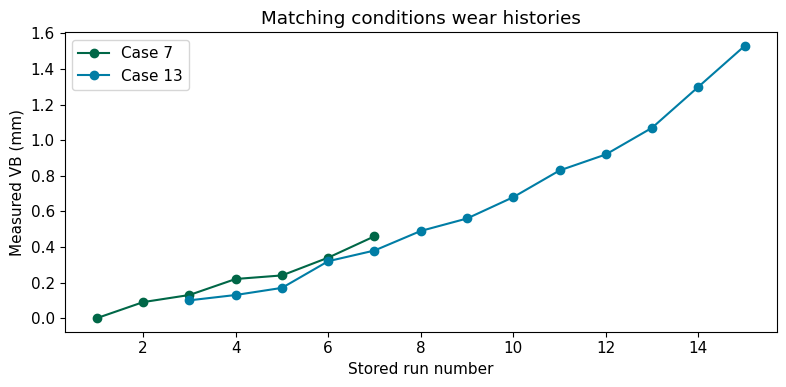

In [ ]:
# Compare measured wear in two experiments with matching conditions.
for case, color in [(7, GREEN), (13, BLUE)]:
    part = usable[usable['case'] == case].sort_values('run')
    plt.plot(part['run'], part['VB'], 'o-', color=color, label=f'Case {case}')

plt.xlabel('Stored run number')
plt.ylabel('Measured VB (mm)')
plt.title('Matching conditions wear histories')
plt.legend()
plt.tight_layout()
plt.show()

**Takeaway:** Matching material, depth, and feed does not guarantee identical wear. Repeat experiments show variability, which may come from physical differences, unrecorded conditions, and measurement noise.

Our model should therefore be evaluated on different experimental sequences, and its predictions should acknowledge uncertainty.

**Question for students:** If operating conditions alone cannot explain all the differences, what additional information might the sensor signals provide?

<details>
<summary>Click to reveal the answer</summary>

Sensor signals may capture differences in the actual cutting process. For example, motor load, vibration, and acoustic activity even when the recorded operating conditions match.

As a tool wears, the level or variability of these signals may change. Features such as the mean and standard deviation could therefore help estimate wear.

We must test this idea: does adding sensors improve predictions compared with using run number and operating conditions alone?

</details>

### Sensor activity: Fix a case, check first and last runs

Keep **Case 3** fixed and compare early and later use: **Run 1, VB 0.00 mm**, and **Run 16, VB 0.55 mm**. Material, feed, and depth stay fixed.

First inspect one current channel, one vibration channel, and one acoustic-emission channel.

1. Which signal changes most in average level? Which changes mainly in variability?
2. Would its **mean**, **standard deviation**, or both be useful model inputs?
3. Does more wear require every sensor's average to increase?

| First three | Recorded measurement |
|---|---|
| `smcDC` | DC spindle motor current |
| `vib_spindle` | Spindle vibration |
| `AE_table` | Table acoustic emission |

Faint lines show the stored readings; bold lines show a **one-second moving average for display only**. Model features will use the complete stored traces. Each panel has its own signal scale; compare changes within a channel, not numerical amplitudes across different sensors.

The spindle-vibration panel uses a **central 99% amplitude view** because a brief large peak otherwise hides its small changes. Some peaks are outside that view; none are deleted from model features.

The stored vibration and acoustic-emission channels were conditioned and RMS processed. These are recorded amplitudes, not invented calibrated units. The documentation describes 250 readings/second.


In [ ]:
# Find the first and last usable labeled runs of one case.
case_number = 3
case_rows = usable[usable['case'] == case_number].sort_values('run')
first_last = case_rows.iloc[[0, -1]]

early_record = raw[int(first_last.iloc[0]['record']) - 1]
late_record = raw[int(first_last.iloc[1]['record']) - 1]

first_channels = ['smcDC', 'vib_spindle', 'AE_table']
remaining_channels = ['smcAC', 'vib_table', 'AE_spindle']
wear_records = [(early_record, 'Early run', GREEN), (late_record, 'Later run', GOLD)]
print(first_last[['case', 'run', 'VB', 'DOC', 'feed', 'material_name']])


    case  run    VB   DOC  feed material_name
25     3    1  0.00  0.75  0.25     Cast iron
38     3   16  0.55  0.75  0.25     Cast iron


In [ ]:
# Reuse one small plotting function for selected sensor channels.
def plot_sensor_pairs(records, channels, title):
    fig, axes = plt.subplots(len(channels), 1, figsize=(10, 2.3 * len(channels)), sharex=True)
    for ax, channel in zip(axes, channels):
        traces = []
        for record, label, color in records:
            signal = np.asarray(getattr(record, channel), dtype=float).ravel()
            traces.append(signal)
            seconds = np.arange(len(signal)) / 250
            smooth = pd.Series(signal).rolling(250, center=True, min_periods=1).mean()

            # Stored readings provide detail; the moving average shows level.
            ax.plot(seconds, signal, color=color, alpha=0.16, linewidth=0.5)
            ax.plot(seconds, smooth, color=color, linewidth=1.5,
                    label=f'{label}: run {int(record.run)}, VB {record.VB:.2f} mm')
        # Zoom this display only; retain all amplitudes in model features.
        if channel == 'vib_spindle':
            ax.set_ylim(np.percentile(np.concatenate(traces), [0.5, 99.5]))
        ax.set_title(f'{CHANNEL_NAMES[channel]} ({channel})', loc='left')
        ax.set_ylabel('Recorded amplitude')
        ax.legend(fontsize=9)

    axes[-1].set_xlabel('Seconds within the recorded trace')
    fig.suptitle(title, fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


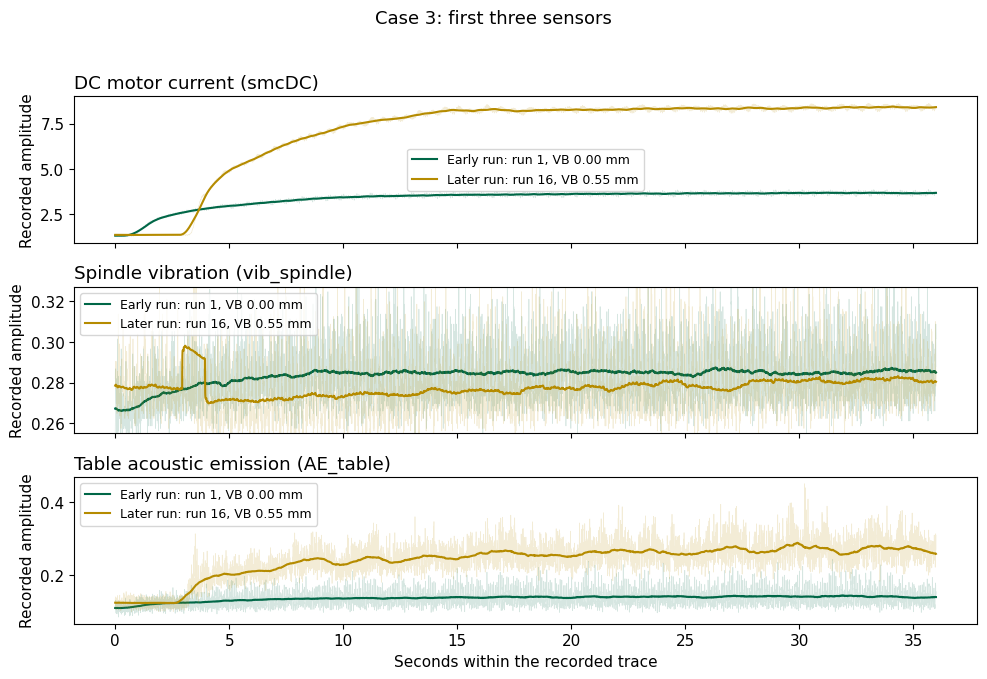

In [ ]:
# Inspect these three before revealing the other sensors.
plot_sensor_pairs(wear_records, first_channels, f'Case {case_number}: first three sensors')

**Pause before the next cell:** predict whether AC current, table vibration, and spindle acoustic emission will support the same story. Record your prediction before revealing them.


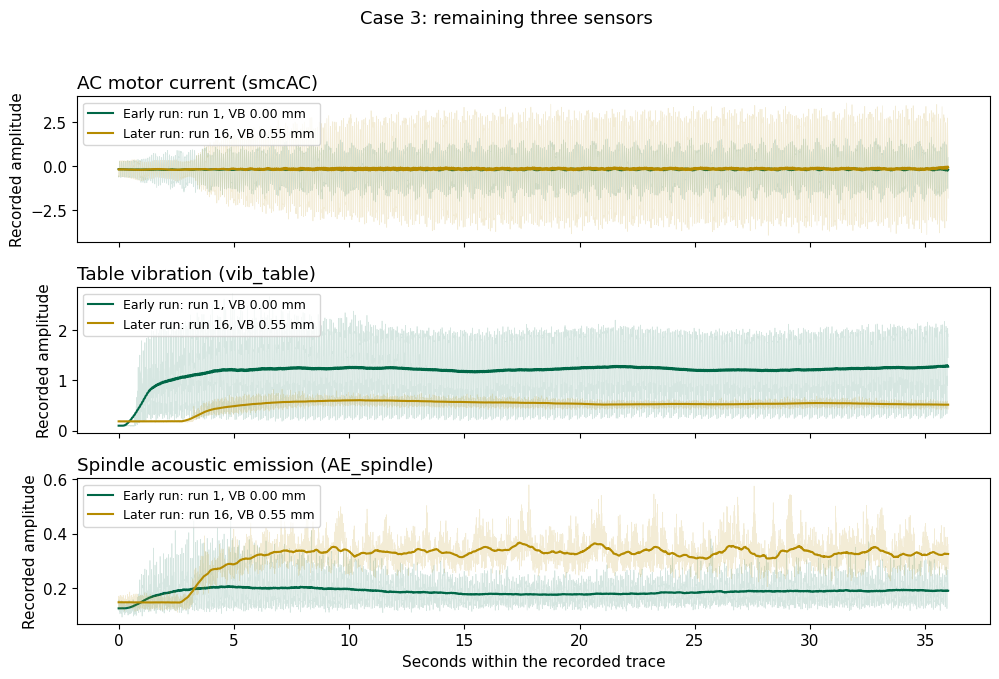

In [ ]:
# remaining three channels for the SAME two runs.
plot_sensor_pairs(wear_records, remaining_channels, f'Case {case_number}: remaining three sensors')


**Overall lesson:** Useful differences can appear in a signal’s level, variability, or other characteristics. We extract features to capture these differences, then test whether they improve predictions on other runs and cases. More sensors do not automatically produce a better model.


**Reconsider:** in the saved Case 3 example, table vibration's average decreases as VB increases. The AC-current average changes little, while its variability increases. A useful feature need not increase with wear; a model can learn a negative association too.


**Try if time permits:** change `case_number` to 7 and rerun the selection and both plot calls. Does the same pattern hold? Choose a case with at least two usable wear labels; Case 6 has only one.


### Optional: Same run, different case

Compare **Case 3 and Case 7, Run 3**. Depth, feed, and measured VB match; the material differs. Focus on two channels rather than another six-panel figure.

| Case | Material | Depth | Feed | Run | VB |
|---|---|---|---|---|---|
| 3 | Cast iron | 0.75 mm | 0.25 mm/rev | 3 | 0.13 mm |
| 7 | Steel | 0.75 mm | 0.25 mm/rev | 3 | 0.13 mm |

In [ ]:
# Choose two runs under matching nominal conditions and measured wear.
run_number = 3
selected_runs = []
for record in raw:
    if record.case in [3, 7] and record.run == run_number:
        selected_runs.append(record)

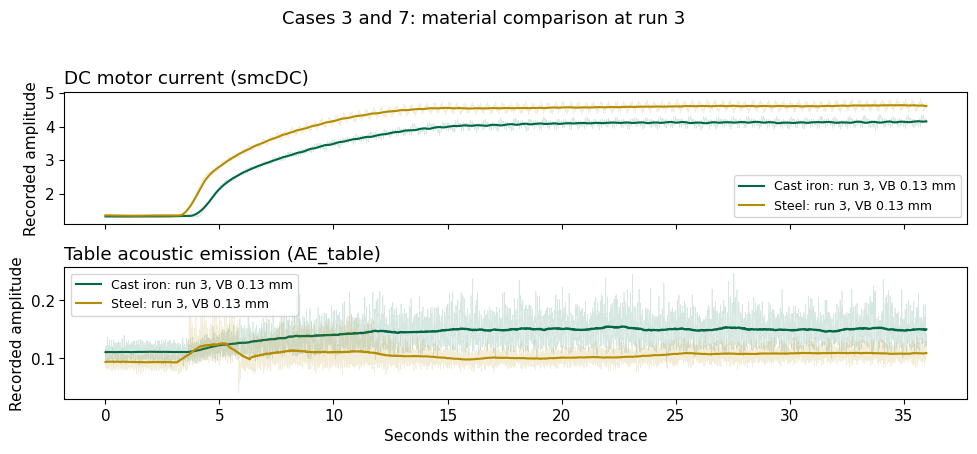

In [ ]:
# Compare two material-sensitive signals at the same measured wear.
material_records = []
for record in selected_runs:
    name = 'Cast iron' if record.material == 1 else 'Steel'
    color = GREEN if record.material == 1 else GOLD
    material_records.append((record, name, color))

plot_sensor_pairs(material_records, ['smcDC', 'AE_table'],
                  f'Cases 3 and 7: material comparison at run {run_number}')


**Discuss:** Signals differ despite matching measured VB. They can respond to material and cutting conditions as well as wear, which motivates including operating context in the model.

Signals also fluctuate within each run. Their variance or standard deviation describes this spread, which may reflect both real changes in the cutting process and sensor noise. We should therefore examine both the average level and the variability.

These two runs do not isolate a causal material effect or tell us how much of the observed variability is noise.

## 3. Build a simple wear estimator

We turn each sensor channels into a **mean** and **standard deviation**. These familiar descriptive statistics become model inputs. One run becomes one feature row.

Six channels × two summaries = **12 sensor features**. Add run number, depth, feed, and the steel indicator: **16 inputs**. `VB` is the target; case is used for grouping, not as a predictor.


In [ ]:
# Summarize every usable run with two statistics per channel.
basic_rows = []
for record_id in usable['record']:
    record = raw[int(record_id) - 1]  # Stored record 1 is Python position 0.
    row = {}
    for channel in CHANNELS:
        signal = np.asarray(getattr(record, channel), dtype=float).ravel()
        row[channel + '_mean'] = signal.mean()
        row[channel + '_std'] = signal.std(ddof=0)
    basic_rows.append(row)

basic_features = pd.DataFrame(basic_rows)
data = pd.concat([usable, basic_features], axis=1)
print(data[['case', 'run', 'VB', 'smcDC_mean', 'smcDC_std', 'AE_table_mean']].head().round(3))

   case  run    VB  smcDC_mean  smcDC_std  AE_table_mean
0     1    1  0.00       5.438      2.244          0.170
1     1    4  0.11       5.828      2.385          0.188
2     1    6  0.20       7.148      2.986          0.208
3     1    7  0.24       7.491      3.224          0.187
4     1    8  0.29       7.819      3.193          0.236


**Feature engineering is a broad and important part of modeling.** It involves choosing, creating, and transforming inputs so that they capture information relevant to the prediction task. Good feature choices often require domain knowledge as well as statistical understanding.

Here, we demonstrate one simple approach: summarize each sensor trace using its **mean** and **standard deviation**.

These summaries capture average level and variability, but may miss information such as peaks, signal shape, and frequency patterns. Later, we will try richer features and check whether they improve predictions.

**The key question:** What information should we preserve from the raw data to help predict wear?

In [ ]:
# Keep entire cases together when separating training and evaluation.
train = data[data['case'] <= 8].copy()
test = data[data['case'] >= 9].copy()

# Context only
context = ['run', 'DOC', 'feed', 'steel']

# Context and basic features
basic_inputs = context + basic_features.columns.tolist()

print('Training runs:', len(train))
print('Evaluation runs:', len(test))
print('Model inputs:', len(basic_inputs))

# Record the wear-label range that the model can learn from.
training_wear_min = train['VB'].min()
training_wear_max = train['VB'].max()
print('Training VB range (mm):', training_wear_min, 'to', training_wear_max)


Training runs: 65
Evaluation runs: 80
Model inputs: 16
Training VB range (mm): 0.0 to 0.74


### Optional: inspect training wear before fitting

The next table describes training wear by material. The groups also mix cutting conditions and wear stages, so differences do not isolate a material effect.

Regression does not require pooled inputs or VB to be normally distributed. The later Gaussian assumption concerns model errors. Runs within a case are correlated, so an independence-based normality test would need care.

Source: [NIST: checking regression error assumptions](https://www.itl.nist.gov/div898/handbook/pri/section2/pri245.htm).


In [ ]:
# Summarize the measured training wear within each material group.
print(train.groupby('material_name')['VB'].agg(['count', 'mean', 'std', 'min', 'median', 'max']).round(3))

               count   mean    std  min  median   max
material_name                                        
Cast iron         46  0.279  0.141  0.0    0.27  0.55
Steel             19  0.273  0.221  0.0    0.24  0.74


Start with a baseline that guesses the **training median VB** for every evaluation run. Then fit Ridge regression, a linear model that shrinks coefficients to help manage correlated inputs.

The pipeline learns scaling from the training set and applies that same scaling during prediction. **`fit` learns from training examples; `predict` estimates wear for other examples.** Alpha controls Ridge shrinkage; our initial setting is 10.

In [ ]:
# Baseline: use one constant wear estimate, learned from training labels.
median_prediction = np.full(len(test), train['VB'].median())

# Fit a scaled linear model, then estimate wear in the evaluation cases.
basic_model = make_pipeline(StandardScaler(), Ridge(alpha=10))
basic_model.fit(train[basic_inputs], train['VB'])
basic_prediction = basic_model.predict(test[basic_inputs])

print('Training-median MAE (mm):', round(mean_absolute_error(test['VB'], median_prediction), 3))
print('Basic-model MAE (mm):', round(mean_absolute_error(test['VB'], basic_prediction), 3))

Training-median MAE (mm): 0.242
Basic-model MAE (mm): 0.121


**Why Ridge regression?**

We start with Ridge because:

- **Our labeled dataset is small.** Regularization can reduce overfitting.
- **Sensor features may contain overlapping information.** Ridge helps stabilize the fitted coefficients when inputs are correlated.
- **It is simple and fast.** We can focus on understanding features, evaluation, and uncertainty.

Ridge is linear regression with a penalty on large coefficients. The parameter `alpha` controls this penalty: larger values produce stronger shrinkage. Too much shrinkage can also lead to underfitting.

We standardize the inputs because their numerical scales differ, learning the scaling from training data only.

**A note on model selection**

Model selection includes choosing the model family, its settings, and its input features. Other models may capture nonlinear relationships that Ridge misses.

These choices should be compared using validation data or cross-validation within the training set. If our goal is prediction for different experimental cases, validation should also hold out complete cases. The final test set should be reserved for evaluation.

For the three-split comparison, we keep the features and Ridge settings fixed. This demonstrates how evaluation changes with the split; it does not identify the best algorithm.

**For inspection decisions:** also examine missed alerts and predictive uncertainty, rather than relying only on average prediction error.

**Why use Mean Absolute Error (MAE)?**

MAE measures the average absolute difference between predicted and measured wear:

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|VB_i-\widehat{VB}_i|
$$

We use MAE because it is easy to interpret and has the same units as VB: **millimeters**.

For example, **MAE = 0.10 mm** means the average absolute prediction error is 0.10 mm across the evaluated runs. Some individual errors may be much larger.

**What other metrics could we use?**

| Metric | What it measures | Interpretation |
|---|---|---|
| **MAE** | Average absolute error | Lower is better; measured in mm |
| **MSE** | Average squared error | Emphasizes large errors; measured in mm² |
| **RMSE** | Square root of MSE | Emphasizes large errors while returning to mm |
| **Median absolute error** | Middle value of the absolute errors | Less influenced by a few extreme errors |
| **R²** | Squared error relative to predicting the evaluation-set mean | 1 is perfect; 0 matches that benchmark; negative is worse |

**Why not percentage error?** Some runs have VB = 0. Dividing by zero or very small wear values makes percentage errors undefined or unstable.

**For our demonstration:** MAE is the main comparison metric. RMSE can additionally show sensitivity to large errors. Neither tells us whether the model misses high-wear tools, so we examine inspection decisions separately.

[Reference: scikit-learn regression metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics)

### Compare four train/test splits

**Question:** does the same model receive the same assessment when we change how its data are separated?

| Split | Training | Testing | Evaluation question |
|---|---|---|---|
| A | Cases 1–8 | Cases 9–16 | Different experimental sequences under repeated conditions |
| B | Cases 9–16 | Cases 1–8 | The reverse transfer between those sequences |
| C | Randomly selected runs | Remaining runs | Held-out runs, mostly from cases represented in training |
| D | Eight randomly selected cases | The other eight cases | Entire experimental cases absent from training |

Use the **same 16 basic inputs and Ridge alpha=10** throughout. Fit a **fresh scaler and model** on each split's training rows, and recalculate its training-median baseline. MAE is our primary comparison; the table also reports RMSE to show sensitivity to large errors.

Split C matches A's **65 training runs and 80 test runs**. Split D matches A's **eight training cases**, but its run counts can differ because cases have different numbers of labeled runs. Both random splits use seed 42.

**Predict before running:** will splitting random runs and splitting random cases give similar errors? Which design represents a different tool's experimental sequence?

Sources: [scikit-learn: grouped observations](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators-for-grouped-data), [random splitting](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), and [training-only preprocessing](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage).

In [ ]:
# Randomly split RUNS, matching Split A's training size.
random_run_train, random_run_test = train_test_split(
    data, train_size=len(train), random_state=42
)

In [ ]:
# Randomly choose eight CASES for training; keep each case's runs together.
case_numbers = sorted(data['case'].unique().tolist())
train_cases, test_cases = train_test_split(
    case_numbers, train_size=8, random_state=42
)

random_case_train = data[data['case'].isin(train_cases)].copy()
random_case_test = data[data['case'].isin(test_cases)].copy()

print('Split D training cases:', sorted(train_cases))
print('Split D testing cases:', sorted(test_cases))
print('Split D runs:', len(random_case_train), 'training;', len(random_case_test), 'testing')

# Define ALL four splits before fitting; retain train/test for later Split A analysis.
splits = [
    ('A: cases 1–8 → 9–16', train, test),
    ('B: cases 9–16 → 1–8', test, train),
    ('C: random runs', random_run_train, random_run_test),
    ('D: random cases', random_case_train, random_case_test)
]

Split D training cases: [3, 4, 5, 7, 8, 11, 13, 16]
Split D testing cases: [1, 2, 6, 9, 10, 12, 14, 15]
Split D runs: 75 training; 70 testing


In [ ]:
# Fit the same model separately; each scaler sees only its training rows.
from sklearn.metrics import mean_squared_error

split_score_rows = []
split_predictions = {}

for name, fit_rows, test_rows in splits:
    split_model = make_pipeline(StandardScaler(), Ridge(alpha=10))
    split_model.fit(fit_rows[basic_inputs], fit_rows['VB'])
    predicted = split_model.predict(test_rows[basic_inputs])

    # The constant baseline also uses only this split's training labels.
    baseline = np.full(len(test_rows), fit_rows['VB'].median())
    split_predictions[name] = predicted
    split_score_rows.append({
        'Split': name,
        'Median MAE (mm)': mean_absolute_error(test_rows['VB'], baseline),
        'Ridge MAE (mm)': mean_absolute_error(test_rows['VB'], predicted),
        'Ridge RMSE (mm)': np.sqrt(mean_squared_error(test_rows['VB'], predicted))
    })

split_scores = pd.DataFrame(split_score_rows)
print(split_scores.round(3))

                 Split  Median MAE (mm)  Ridge MAE (mm)  Ridge RMSE (mm)
0  A: cases 1–8 → 9–16            0.242           0.121            0.201
1  B: cases 9–16 → 1–8            0.147           0.113            0.172
2       C: random runs            0.200           0.086            0.122
3      D: random cases            0.177           0.134            0.183


**Discuss:** Which splits keep entire experimental cases out of training? If random runs give a lower error, does that establish better performance on a different tool?

<details>
<summary>Reveal the answer</summary>

**A, B, and D** hold out entire cases. **C** can place related runs from the same case in both training and testing.

For a new-tool or new-case claim, this overlap can give an optimistic assessment; it is often called group leakage. It does not require VB to have been used as an input. Runs still share an experimental sequence. A random-run split can serve a different task, such as estimating unmeasured wear in a familiar sequence, but it does not establish new-case performance or enforce forward time order.

Random cases provide another choice of held-out sequences. They do not automatically guarantee new cutting conditions: repeat cases can share nominal conditions.

</details>

**Follow-up:** Why does the median baseline's error also change, even though it uses no sensor information?

<details>
<summary>Reveal the answer</summary>

Each split learns its median from a different training set and predicts a different test population. Wear distributions, ranges, and sample counts can change.

Therefore, compare both model errors and the split information below. The score differences do not isolate case overlap as the only cause.

</details>

In [ ]:
# Describe case overlap and wear coverage for each split.
split_details = []
for name, fit_rows, test_rows in splits:
    shared = set(fit_rows['case']) & set(test_rows['case'])
    split_details.append({
        'Split': name,
        'Train runs': len(fit_rows),
        'Test runs': len(test_rows),
        'Shared cases': len(shared),
        'Train VB range': f"{fit_rows['VB'].min():.2f}–{fit_rows['VB'].max():.2f}",
        'Test VB range': f"{test_rows['VB'].min():.2f}–{test_rows['VB'].max():.2f}",
        'Test VB above train max': (test_rows['VB'] > fit_rows['VB'].max()).sum()
    })

split_information = pd.DataFrame(split_details)
print(split_information)


                 Split  Train runs  Test runs  Shared cases Train VB range  \
0  A: cases 1–8 → 9–16          65         80             0      0.00–0.74   
1  B: cases 9–16 → 1–8          80         65             0      0.00–1.53   
2       C: random runs          65         80            15      0.00–1.30   
3      D: random cases          75         70             0      0.00–1.53   

  Test VB range  Test VB above train max  
0     0.00–1.53                        9  
1     0.00–0.74                        0  
2     0.00–1.53                        1  
3     0.00–1.14                        0  


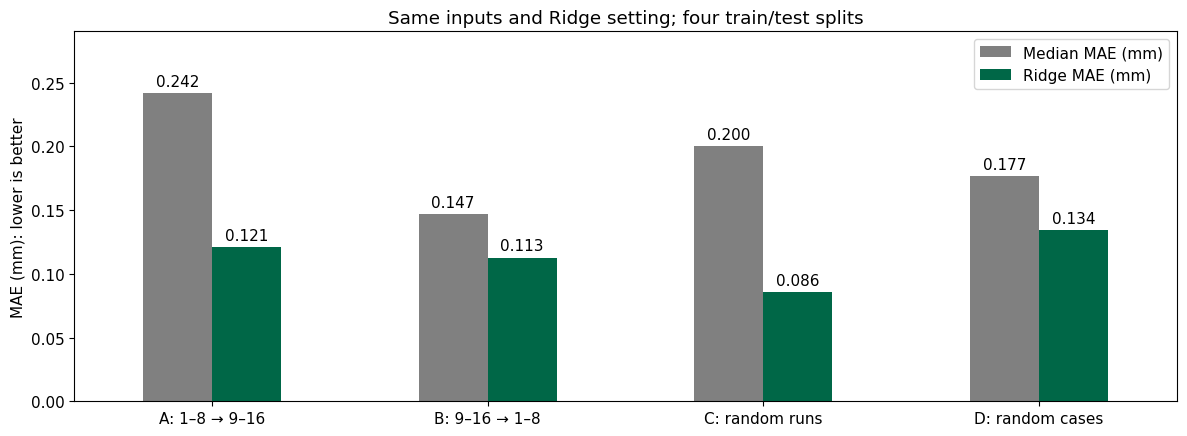

In [ ]:
# Compare MAE across the four designs; RMSE remains in the results table.
mae_columns = ['Median MAE (mm)', 'Ridge MAE (mm)']
ax = split_scores.set_index('Split')[mae_columns].plot.bar(
    color=['grey', GREEN], figsize=(12, 4.5), rot=0
)
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_xticklabels(['A: 1–8 → 9–16', 'B: 9–16 → 1–8',
                    'C: random runs', 'D: random cases'])
ax.set_ylabel('MAE (mm): lower is better')
ax.set_xlabel('')
ax.set_title('Same inputs and Ridge setting; four train/test splits')
ax.set_ylim(0, split_scores[mae_columns].to_numpy().max() * 1.2)
plt.tight_layout()
plt.show()

### Optional: inspect the individual errors

Each point below is one test run. The diagonal marks a perfect estimate. The gold band marks **that split's training wear range**, so its width changes when the training cases change.


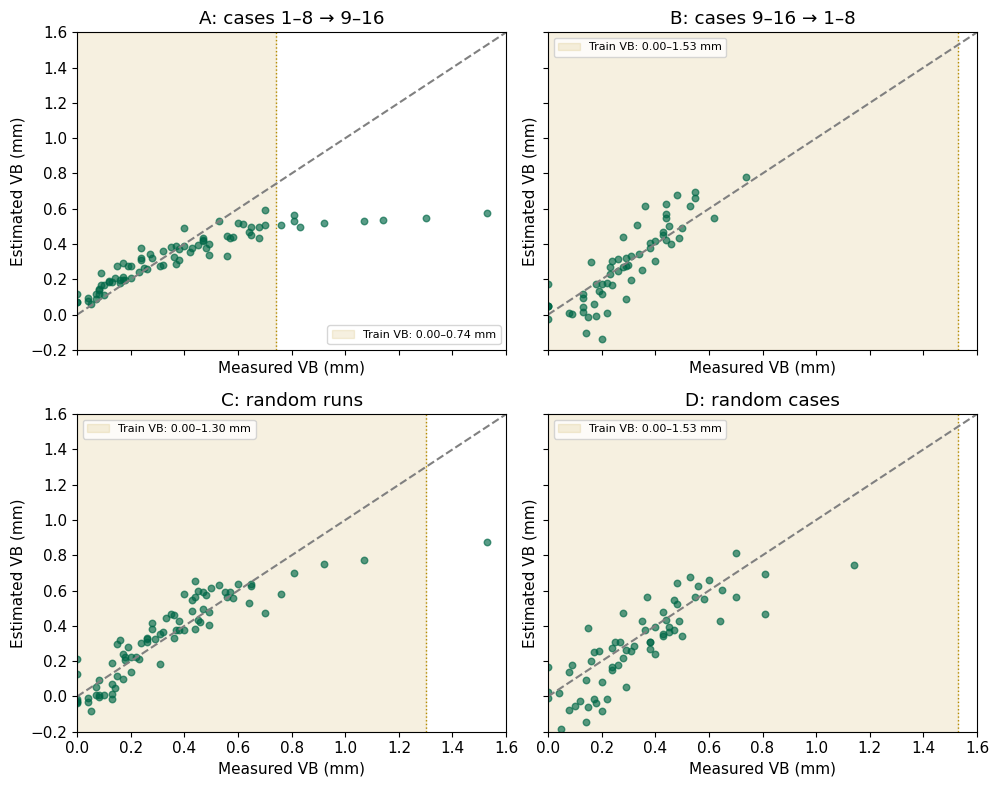

In [ ]:
# Use common axes and each split's own training wear range.
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

for ax, (name, fit_rows, test_rows) in zip(axes.flat, splits):
    low, high = fit_rows['VB'].min(), fit_rows['VB'].max()
    ax.axvspan(low, high, color=GOLD, alpha=0.12,
               label=f'Train VB: {low:.2f}–{high:.2f} mm')
    ax.axvline(high, color=GOLD, linestyle=':', linewidth=1)
    ax.scatter(test_rows['VB'], split_predictions[name], color=GREEN, alpha=0.65, s=22)
    ax.plot([0, 1.6], [0, 1.6], '--', color='grey')
    ax.set(title=name, xlabel='Measured VB (mm)', ylabel='Estimated VB (mm)',
           xlim=(0, 1.6), ylim=(-0.2, 1.6))
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

**Read the saved example:** Ridge MAE is **0.121 mm in A**, **0.113 mm in B**, **0.086 mm in C**, and **0.134 mm in D**. C shares **15 cases** across training and testing; A, B, and D share none. A lower score on familiar sequences does not establish equally good new-case performance.

D trains on **75 runs from eight cases** and tests on **70 runs from the other eight**. Its training VB range is **0.00–1.53 mm** and its test range is **0.00–1.14 mm**. **0** test labels exceed its training maximum.

In this random-case draw, training and testing each contain **five nominal cutting conditions**, with only **two conditions shared**. A and B each share all eight conditions through the repeat pairs. Therefore, C versus D changes more than case overlap: the run counts, conditions, and wear distributions also change.

**The takeaways:**

- A split defines the generalization question: new sequences or held-out runs from familiar sequences.
- A and B represent all eight nominal cutting conditions on both sides through their repeat pairs. Random cases can put both repeats together, changing which conditions are represented in training and testing.
- Training wear coverage also changes the prediction challenge. A holds out some advanced wear; reversing the direction is a different task.
- Compare baseline errors, sample counts, case overlap, and wear ranges alongside MAE. These different test populations do not isolate one cause for an error difference.
- Keep cases together when estimating performance for new tools. Use a forward-time evaluation if the intended task is predicting later runs from earlier ones.

**Discuss:** which design best matches your intended use? What would you check before relying on one random-case result?

<details>
<summary>Reveal the answer</summary>

For a different tool's experimental sequence, prefer case-held-out evaluation such as A, B, or D. Check whether the training data cover relevant conditions and wear levels. In a larger study, repeat grouped validation or use several group folds to examine sensitivity to which cases are held out; do not select the easiest random seed.

</details>

## 4. Add richer sensor features

Could more detailed summaries help? We will calculate ten features per channel:

| Summary | What it captures |
|---|---|
| Mean and standard deviation | Average level and variation |
| P10, median, P90 | Lower, middle, and upper parts of the distribution |
| IQR | P75 − P25: spread of the middle half |
| RMS | Overall signal magnitude |
| Skewness | Asymmetry of the amplitude distribution |
| Excess kurtosis | Standardized fourth moment; tail behavior relative to a Gaussian |
| Histogram entropy | How evenly readings occupy amplitude bins |

P10 and P90 are **percentiles**; P25 and P75 are quartiles. Histogram entropy ignores time order: shuffling a trace leaves it unchanged. Higher entropy does not automatically mean higher wear.

For entropy, first learn one set of 20 amplitude bins per channel from **training traces only**. We use those same boundaries for all evaluation runs. Outer bins include readings beyond the training range.

Source: [SciPy entropy documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.entropy.html).

In [ ]:
# Learn common histogram boundaries from the training sensor readings.
entropy_bins = {}
for channel in CHANNELS:
    training_signals = []
    for record_id in train['record']:
        record = raw[int(record_id) - 1]
        signal = np.asarray(getattr(record, channel), dtype=float).ravel()
        training_signals.append(signal)

    readings = np.concatenate(training_signals)
    edges = np.linspace(readings.min(), readings.max(), 21)  # 20 bins
    edges[0], edges[-1] = -np.inf, np.inf
    entropy_bins[channel] = edges

In [ ]:
# Calculate the richer summaries for one run; reuse this function below.
def summarize_run(record):
    row = {}
    for channel in CHANNELS:
        signal = np.asarray(getattr(record, channel), dtype=float).ravel()
        p10, p25, median, p75, p90 = np.percentile(signal, [10, 25, 50, 75, 90])
        counts, _ = np.histogram(signal, bins=entropy_bins[channel])

        # Familiar measures of level and spread.
        row[channel + '_mean'] = signal.mean()
        row[channel + '_std'] = signal.std(ddof=0)
        row[channel + '_p10'] = p10
        row[channel + '_median'] = median
        row[channel + '_p90'] = p90
        row[channel + '_iqr'] = p75 - p25

        # Signal magnitude, distribution shape, and histogram entropy.
        row[channel + '_rms'] = np.sqrt(np.mean(signal ** 2))
        row[channel + '_skewness'] = skew(signal, bias=True)
        row[channel + '_kurtosis'] = kurtosis(signal, fisher=True, bias=True)
        row[channel + '_entropy'] = entropy(counts, base=2)
    return row

In [ ]:
# Build a separate richer-feature table with one row per usable run.
rich_rows = []
for record_id in usable['record']:
    rich_rows.append(summarize_run(raw[int(record_id) - 1]))

rich_features = pd.DataFrame(rich_rows)
print('Sensor features per run:', rich_features.shape[1])
print(rich_features[['smcDC_mean', 'smcDC_p10', 'smcDC_p90', 'smcDC_rms', 'smcDC_entropy']].head().round(3))

Sensor features per run: 60
   smcDC_mean  smcDC_p10  smcDC_p90  smcDC_rms  smcDC_entropy
0       5.438      1.484      7.222      5.883          2.816
1       5.828      1.479      7.671      6.297          2.865
2       7.148      1.528      9.458      7.747          3.052
3       7.491      1.440      9.995      8.155          2.646
4       7.819      1.450      9.995      8.445          2.399


In [ ]:
# Use the SAME run split, then add the four context inputs.
rich_train = rich_features.loc[train.index]
rich_test = rich_features.loc[test.index]
X_train_rich = pd.concat([train[context], rich_train], axis=1)
X_test_rich = pd.concat([test[context], rich_test], axis=1)

print('Total richer-model inputs:', X_train_rich.shape[1])

Total richer-model inputs: 64


**Predict before running:** will using all 64 inputs automatically improve the model?

Fit both the basic inputs and all 64 richer inputs at alpha=1. Comparing all richer inputs with the selected subset at the same alpha separates the input-subset change from the regularization change.

**Prepared settings:** the instructor compared settings by holding out one complete training case at a time. That preparation selected alpha=1 and a subset size of 24 sensor features. We keep those settings fixed here; no long parameter search runs during class.

### Do the sensors add information?

A constant baseline cannot tell us whether sensors help beyond run number and cutting conditions. Compare **context only**, **12 sensor summaries only**, and their combination at the same **alpha=1**. Context means `run`, `DOC`, `feed`, and `steel`.

Scaling is fitted using training examples for each model. These are comparisons at a fixed teaching setting; we have not separately optimized each baseline.

**Discuss:** if the combined model beats the constant baseline, have we established that its sensors helped?

In [ ]:
# Fit two baselines that separate context inputs from sensor inputs.
context_model = make_pipeline(StandardScaler(), Ridge(alpha=1))
context_model.fit(train[context], train['VB'])
context_prediction = context_model.predict(test[context])

sensor_inputs = basic_features.columns.tolist()
sensors_model = make_pipeline(StandardScaler(), Ridge(alpha=1))
sensors_model.fit(train[sensor_inputs], train['VB'])
sensors_prediction = sensors_model.predict(test[sensor_inputs])

### Check the sensor hypothesis with prediction errors

Return to the three sensors shown first and the three revealed later. Visual change in one case is a hypothesis, not proof of predictive usefulness.

Compare **first three**, **remaining three**, and **all six**. Every model includes the same four context inputs (`run`, `DOC`, `feed`, `steel`), uses only sensor **means and standard deviations**, and uses **alpha=1 on Split A**. Each three-sensor model has 10 inputs; the all-six model has 16.

**Predict:** will all six necessarily beat either three-sensor group? Write your prediction before running.


In [ ]:
# Compare the two visual groups and all six with the same context and alpha.
sensor_groups = {'First three': first_channels,
                 'Remaining three': remaining_channels, 'All six': CHANNELS}
sensor_group_rows = []
for name, channels in sensor_groups.items():
    columns = context.copy()
    for channel in channels:
        columns += [channel + '_mean', channel + '_std']
    group_model = make_pipeline(StandardScaler(), Ridge(alpha=1))
    group_model.fit(train[columns], train['VB'])
    group_prediction = group_model.predict(test[columns])
    sensor_group_rows.append({'Sensor group': name, 'Inputs': len(columns),
        'MAE (mm)': mean_absolute_error(test['VB'], group_prediction)})

sensor_group_scores = pd.DataFrame(sensor_group_rows)
print(sensor_group_scores.round(3))


      Sensor group  Inputs  MAE (mm)
0      First three      10     0.103
1  Remaining three      10     0.129
2          All six      16     0.114


**Read the saved example:** first three plus context gives **0.103 mm**, remaining three plus context gives **0.129 mm**, and all six plus context gives **0.114 mm**. More sensor inputs do not automatically give lower error in this example.

This compares predefined groups, not each sensor's individual contribution. It does not prove the first group is best for every case. The context inputs remain in every model; the sensors-only and context-only comparison separately checks whether sensors help beyond context.

**Discuss:** did your visual prediction agree with the MAEs? What additional cases would you want to examine before choosing a sensor configuration?


In [ ]:
# Test all richer inputs using the original Ridge setting.
all_features_model = make_pipeline(StandardScaler(), Ridge(alpha=10))
all_features_model.fit(X_train_rich, train['VB'])
all_features_prediction = all_features_model.predict(X_test_rich)

# Fit original features at alpha=1 for a comparison at the same setting.
basic_alpha1_model = make_pipeline(StandardScaler(), Ridge(alpha=1))
basic_alpha1_model.fit(train[basic_inputs], train['VB'])
basic_alpha1_prediction = basic_alpha1_model.predict(test[basic_inputs])

# Use all richer inputs at alpha=1 for the matched-subset comparison.
all_features_alpha1_model = make_pipeline(StandardScaler(), Ridge(alpha=1))
all_features_alpha1_model.fit(X_train_rich, train['VB'])
all_features_alpha1_prediction = all_features_alpha1_model.predict(X_test_rich)

Some summaries overlap. We will retain **24 sensor features**, ranked by their individual linear association with VB in the **training data**. The four context inputs stay in the model.

This simple ranking is a predictive selection, not proof that selected sensors cause wear or omitted sensors are useless.

In [ ]:
# Learn which sensor summaries to retain, using training labels only.
selector = SelectKBest(score_func=f_regression, k=24)
selector.fit(rich_train, train['VB'])
selected_sensors = rich_features.columns[selector.get_support()].tolist()

# Keep the four context inputs alongside those selected sensor features.
selected_inputs = context + selected_sensors
X_train_selected = X_train_rich[selected_inputs]
X_test_selected = X_test_rich[selected_inputs]

print('Selected sensor features:', len(selected_sensors))
print('Total selected-model inputs:', len(selected_inputs))

Selected sensor features: 24
Total selected-model inputs: 28


In [ ]:
# Fit the selected-feature model and estimate wear in the same evaluation runs.
selected_model = make_pipeline(StandardScaler(), Ridge(alpha=1))
selected_model.fit(X_train_selected, train['VB'])
selected_prediction = selected_model.predict(X_test_selected)

In [ ]:
# Compare the baselines and input sets using the same measured evaluation labels.
predictions = {
    'Training median': median_prediction,
    'Context only; alpha=1': context_prediction,
    'Basic sensors only; alpha=1': sensors_prediction,
    'Basic sensors + context; alpha=10': basic_prediction,
    'All richer features; alpha=10': all_features_prediction,
    'Basic sensors + context; alpha=1': basic_alpha1_prediction,
    'All richer features; alpha=1': all_features_alpha1_prediction,
    'Selected richer features; alpha=1': selected_prediction
}

score_rows = []
for name, prediction in predictions.items():
    score_rows.append({'Model': name, 'MAE_mm': mean_absolute_error(test['VB'], prediction)})
scores = pd.DataFrame(score_rows)
print(scores.round(3))

                               Model  MAE_mm
0                    Training median   0.242
1              Context only; alpha=1   0.142
2        Basic sensors only; alpha=1   0.139
3  Basic sensors + context; alpha=10   0.121
4      All richer features; alpha=10   0.127
5   Basic sensors + context; alpha=1   0.114
6       All richer features; alpha=1   0.152
7  Selected richer features; alpha=1   0.106


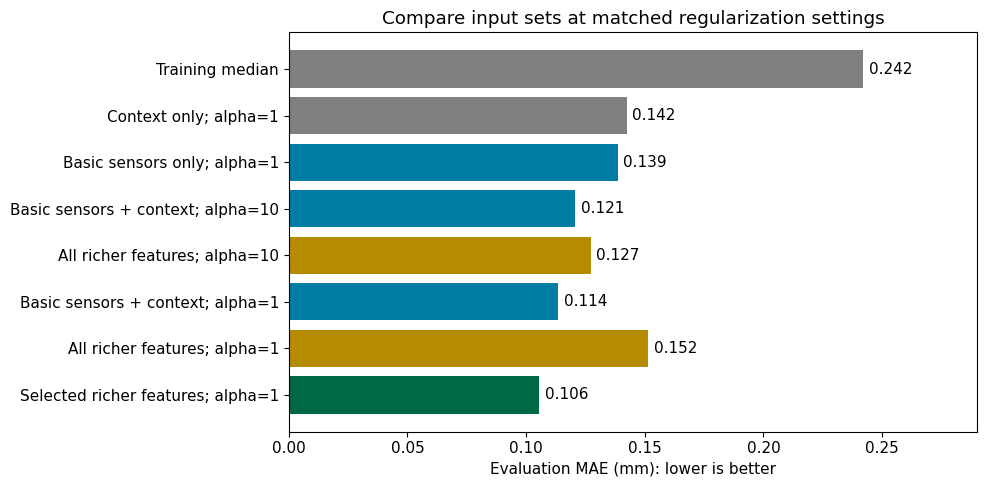

In [ ]:
# Make the before-and-after comparison easier to read.
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(scores['Model'], scores['MAE_mm'], color=['grey', 'grey', BLUE, BLUE, GOLD, BLUE, GOLD, GREEN])
ax.bar_label(bars, fmt='%.3f', padding=4)
ax.invert_yaxis()
ax.set_xlim(0, 0.29)
ax.set_xlabel('Evaluation MAE (mm): lower is better')
ax.set_title('Compare input sets at matched regularization settings')
plt.tight_layout()
plt.show()

**Read the comparisons:** at alpha=1, context-only MAE is **0.142 mm**, sensors-only MAE is **0.139 mm**, and combining context with the 12 sensor summaries gives **0.114 mm**. The sensors improve average prediction beyond context on this split.

At the same alpha=1, all 64 richer inputs give **0.152 mm**, while the selected 28 inputs give **0.106 mm**. This supports a subset benefit for these fitted models. The selected model's gain over the basic 16-input model is smaller: about **0.008 mm**. The total improvement from the constant baseline cannot be credited to sensors alone.

**Discuss:** why might adding many correlated summaries make prediction worse?

Now inspect individual estimates. A point below the diagonal means the model underestimated wear. Linear regression can also return negative estimates near zero; we have not clipped them. This plot uses measured wear, so it is an evaluation diagnostic, not something available when wear is unknown.

The gold band in the next figure marks the **training wear-label range, 0.00–0.74 mm**. Its horizontal position corresponds to measured wear. Points beyond it have measured wear above the training maximum; this is a retrospective diagnostic, not an online detector.

### Does improvement hold across cases?

The overall MAE averages **80 runs**, with different numbers of runs per case. Runs within a case are related, so they are not 80 independent experiments. Inspect the **eight case-level MAEs** at the same alpha=1.

The last column is selected-model MAE minus basic-model MAE. A negative value means the selected model improved that case.

In [ ]:
# Calculate errors for each run, then average within each evaluation case.
case_errors = test[['case']].copy()
case_errors['Basic'] = np.abs(test['VB'] - basic_alpha1_prediction)
case_errors['All richer'] = np.abs(test['VB'] - all_features_alpha1_prediction)
case_errors['Selected richer'] = np.abs(test['VB'] - selected_prediction)

case_mae = case_errors.groupby('case').mean()
case_mae.insert(0, 'Labeled runs', test.groupby('case').size())
case_mae['Selected minus basic'] = case_mae['Selected richer'] - case_mae['Basic']
print(case_mae.round(3))

      Labeled runs  Basic  All richer  Selected richer  Selected minus basic
case                                                                        
9                9  0.087       0.111            0.080                -0.007
10              10  0.038       0.079            0.039                 0.001
11              20  0.100       0.116            0.090                -0.010
12              12  0.069       0.086            0.057                -0.012
13              13  0.239       0.314            0.216                -0.022
14               7  0.170       0.183            0.165                -0.006
15               6  0.066       0.188            0.077                 0.011
16               3  0.130       0.159            0.136                 0.006


The selected model improves **five cases** and worsens **three** compared with the basic model at alpha=1. Its run-weighted MAE improves by about **0.008 mm**. Giving each case equal weight changes the average from **0.112 to 0.108 mm**, a smaller improvement.

At alpha=1, selecting a subset also improves over using all 64 inputs in **all eight evaluation cases**. These are observed results on this split, not proof that the procedure will always improve future cases. We have not established statistical significance; a small gap alone does not prove that it is noise.

**Discuss:** would one overall score have revealed which cases became worse?

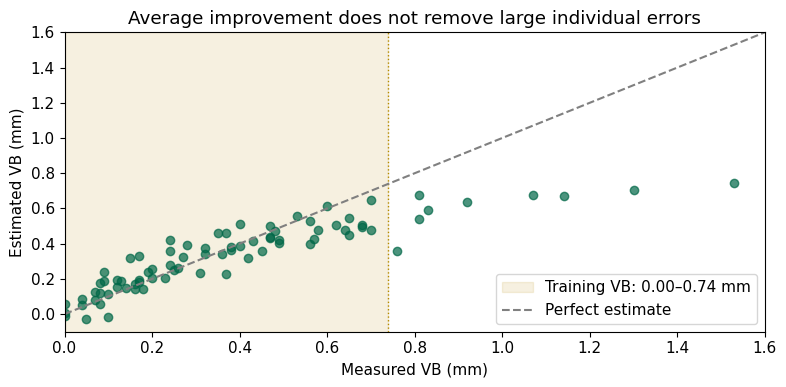

In [ ]:
# Compare individual measured and estimated wear values.
plt.axvspan(training_wear_min, training_wear_max, color=GOLD, alpha=0.12,
            label=f'Training VB: {training_wear_min:.2f}–{training_wear_max:.2f} mm')
plt.axvline(training_wear_max, color=GOLD, linestyle=':', linewidth=1)
plt.scatter(test['VB'], selected_prediction, color=GREEN, alpha=0.7)
plt.plot([0, 1.6], [0, 1.6], '--', color='grey', label='Perfect estimate')
plt.xlim(0, 1.6)
plt.ylim(-0.1, 1.6)  # Include the model's few negative estimates near zero.
plt.xlabel('Measured VB (mm)')
plt.ylabel('Estimated VB (mm)')
plt.title('Average improvement does not remove large individual errors')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Predict a range, then check it

A point estimate does not say how uncertain the prediction is. We now use **Bayesian linear regression**, with the same selected inputs, to obtain a predictive mean and standard deviation.

`BayesianRidge` is an empirical Bayes implementation: it estimates noise and regularization from training data. Its predictive uncertainty accounts for coefficient uncertainty and Gaussian residual noise, conditional on those estimates. Being Bayesian does not guarantee correct interval coverage.

Source: [BayesianRidge documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.BayesianRidge.html).

In [ ]:
# Learn scaling from training inputs; reuse it for evaluation inputs.
scaler = StandardScaler()
scaled_train = scaler.fit_transform(X_train_selected)
scaled_test = scaler.transform(X_test_selected)

# Return an estimated wear value and predictive spread for each run.
bayesian_model = BayesianRidge()
bayesian_model.fit(scaled_train, train['VB'])
wear_mean, wear_std = bayesian_model.predict(scaled_test, return_std=True)

print('Bayesian-model MAE (mm):', round(mean_absolute_error(test['VB'], wear_mean), 3))

Bayesian-model MAE (mm): 0.105


For a Gaussian predictive distribution, the central **90% predictive interval** is approximately:

$$\text{estimated wear}\ \pm\ 1.645\times\text{predictive standard deviation}.$$

This is an interval for an individual wear measurement. It is not the MAE or an interval only for the average response.

In [ ]:
# Choose the intended coverage, then calculate each run's interval.
interval_level = 0.90
multiplier = norm.ppf((1 + interval_level) / 2)  # 1.645 for a 90% interval
lower = wear_mean - multiplier * wear_std
upper = wear_mean + multiplier * wear_std

# Coverage: the fraction of measured values that fall inside their intervals.
inside = (test['VB'].to_numpy() >= lower) & (test['VB'].to_numpy() <= upper)
print('Measurements inside intervals:', inside.sum(), 'out of', len(test))
print('Observed coverage:', f'{inside.mean():.1%}')
print('Average interval width (mm):', round(np.mean(upper - lower), 3))

Measurements inside intervals: 61 out of 80
Observed coverage: 76.2%
Average interval width (mm): 0.257


In [ ]:
# Keep the measured wear, estimate, and interval together for each run.
evaluation = test[['case', 'run', 'VB']].copy()
evaluation['estimated_VB'] = wear_mean
evaluation['lower'] = lower
evaluation['upper'] = upper
evaluation['inside_interval'] = inside
evaluation.head().round(3)

,case,run,VB,estimated_VB,lower,upper,inside_interval
46,9,1,0.00,-0.005,-0.125,0.115,True
47,9,2,0.10,-0.009,-0.129,0.110,True
48,9,3,0.14,0.149,0.030,0.269,True
49,9,4,0.19,0.238,0.118,0.358,True
50,9,5,0.27,0.316,0.193,0.439,True


**Discuss:** 90% of 80 is 72. Our intervals contain only **61 of 80** measurements, or **76.25%**. What does that tell us about the stated uncertainty?

The figure below shows one illustrative difficult case; the coverage calculation above used all eight evaluation cases. Some Gaussian lower bounds can be negative. That reflects the approximation, not physically negative wear; we leave the intervals unaltered for this coverage check.

In the next figure, **gold** marks the wear-label range seen during training; **green** marks the model's predictive interval for each evaluation run. These bands represent different quantities.

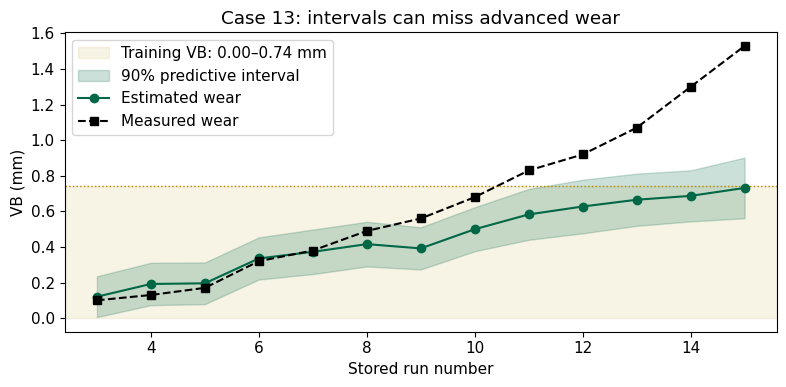

In [ ]:
# Plot estimated wear and its interval across one evaluation case.
case_to_plot = 13
part = evaluation[evaluation['case'] == case_to_plot].sort_values('run')
plt.axhspan(training_wear_min, training_wear_max, color=GOLD, alpha=0.10,
            label=f'Training VB: {training_wear_min:.2f}–{training_wear_max:.2f} mm')
plt.axhline(training_wear_max, color=GOLD, linestyle=':', linewidth=1)
plt.fill_between(part['run'], part['lower'], part['upper'], color=GREEN, alpha=0.2,
                 label=f'{interval_level:.0%} predictive interval')
plt.plot(part['run'], part['estimated_VB'], 'o-', color=GREEN, label='Estimated wear')
plt.plot(part['run'], part['VB'], 's--', color='black', label='Measured wear')
plt.xlabel('Stored run number')
plt.ylabel('VB (mm)')
plt.title(f'Case {case_to_plot}: intervals can miss advanced wear')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate a simple illustrative alert rule using point estimates.
threshold = 0.70
measured_exceedance = test['VB'].to_numpy() >= threshold
estimated_exceedance = selected_prediction >= threshold

missed = measured_exceedance & ~estimated_exceedance
false_alert = ~measured_exceedance & estimated_exceedance
print('Measured threshold exceedances:', measured_exceedance.sum())
print('Missed exceedances:', missed.sum())
print('False alerts:', false_alert.sum())

Measured threshold exceedances: 11
Missed exceedances: 9
False alerts: 0


**Measured exceedances:** The number of runs where the measured wear (VB) is **at or above the inspection threshold**.

**Missed exceedances:** The number of those runs where the inspection rule **fails to raise an alert**. For a rule based on the point prediction, this happens when predicted wear is below the threshold.

**Example:** With a threshold of **0.70 mm**, a run with measured VB of **0.80 mm** is a measured exceedance. If predicted VB is **0.60 mm**, no alert is raised, so it is also a missed exceedance.

**False alerts:** The number of runs where the inspection rule **raises an alert even though measured wear is below the threshold**.

**Example:** With a threshold of **0.70 mm**, measured VB of **0.50 mm** and predicted VB of **0.80 mm** produce a false alert.

A false alert may lead to an unnecessary inspection; a missed exceedance may leave a worn tool unchecked.

### Compare two inspection rules and two thresholds

Use **0.40 mm**, inside the training wear range, and **0.70 mm**, near its upper end. Both are illustrative teaching thresholds, not approved tool-replacement limits.

Compare rules using the **same Bayesian model**, so a change in model does not confound the comparison:

- **Mean rule:** inspect when estimated mean wear reaches the threshold.
- **Upper-bound rule:** inspect when the upper end of the 90% predictive interval reaches the threshold.

The upper-bound rule also flags uncertain cases that might be above the threshold. It does not mean there is a 90% probability that wear has already exceeded it. Our interval coverage was only **76.25%**, so this rule is not a calibrated safety guarantee.

**Predict before running:** which rule should miss fewer exceedances, and which may produce more unnecessary inspections?

In [ ]:
# Compare mean and upper-bound alerts using the same model and runs.
thresholds = [0.40, 0.70]
alert_rows = []

for limit in thresholds:
    measured_high = test['VB'].to_numpy() >= limit
    for rule, values in [('Mean', wear_mean), ('Upper bound', upper)]:
        alert = values >= limit
        alert_rows.append({
            'Threshold (mm)': limit,
            'Rule': rule,
            'Measured exceedances': measured_high.sum(),
            'Missed exceedances': (measured_high & ~alert).sum(),
            'False alerts': (~measured_high & alert).sum()
        })

alert_comparison = pd.DataFrame(alert_rows)
print(alert_comparison)

   Threshold (mm)         Rule  Measured exceedances  Missed exceedances  \
0             0.4         Mean                    34                   5   
1             0.4  Upper bound                    34                   0   
2             0.7         Mean                    11                  10   
3             0.7  Upper bound                    11                   3   

   False alerts  
0             3  
1            13  
2             0  
3             1  


**Read the trade-off:** at 0.40 mm, the mean rule misses **5 of 34** exceedances and gives **3 false alerts**. The upper-bound rule misses **0**, while false alerts increase to **13**. At 0.70 mm, misses decrease from **10 to 3**, while false alerts increase from **0 to 1**.

The original Ridge rule and the Bayesian mean rule can differ: they are different fitted models. The table above uses Bayesian predictions for both rules.

### Separate errors within and beyond the observed training wear range

For diagnosis, split the evaluation runs using their **measured** VB and check the original Ridge point rule. This requires measured wear and is available only during evaluation; it is not an online detector.

In [ ]:
# Locate missed Ridge alerts using measured wear as an evaluation diagnostic.
range_rows = []
within_range = test['VB'].to_numpy() <= training_wear_max

for limit in thresholds:
    measured_high = test['VB'].to_numpy() >= limit
    ridge_alert = selected_prediction >= limit
    for name, mask in [('Within training VB range', within_range),
                       ('Above training VB range', ~within_range)]:
        range_rows.append({
            'Threshold (mm)': limit,
            'Measured wear group': name,
            'Measured exceedances': (measured_high & mask).sum(),
            'Missed exceedances': (measured_high & ~ridge_alert & mask).sum()
        })

range_diagnostic = pd.DataFrame(range_rows)
print(range_diagnostic)

   Threshold (mm)       Measured wear group  Measured exceedances  \
0             0.4  Within training VB range                    25   
1             0.4   Above training VB range                     9   
2             0.7  Within training VB range                     2   
3             0.7   Above training VB range                     9   

   Missed exceedances  
0                   4  
1                   1  
2                   2  
3                   7  


At 0.70 mm, **7 of the 9** missed Ridge alerts occur above the training maximum. However, it also misses **both** exceedances whose measured wear is within the training range. At 0.40 mm, it misses **4 of 25** within-range exceedances.

The high-wear gap matters, but it does not explain every missed alert. Linear models can extrapolate; this model's fitted relationship underestimates many high-wear observations. These results do not isolate a single cause.

**Discuss:** would you accept additional inspections to reduce missed exceedances? What costs and reliability requirements would determine that choice?

### What we gained

- Explored the milling data, turned sensor readings into features,
- Built models to estimate tool wear
- Compared four data splits and different feature sets to examine how they affect prediction errors
- Checked predictive uncertainty and compared inspection rules, connecting model performance to the trade-off between missed high wear and unnecessary inspections.

These comparisons are exploratory demonstrations intended for learning. They illustrate how data splitting, feature engineering, and model choices affect wear estimates and uncertainty. The takeaway is to evaluate models according to their intended use and examine inspection errors alongside average prediction accuracy. Before guiding maintenance decisions, the system would need validation on fresh tool cases, reliable uncertainty estimates, and inspection rules that account for missed wear and unnecessary inspections.

## References

- [NASA PCoE repository](https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/), Milling entry; data provided by UC Berkeley BEST Lab. The archive's Goebel & Agogino *Documentation for Mill Data Set* supplies the case conditions, channels, and microscope measurement method.
- [SciPy entropy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.entropy.html), [skewness](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skew.html), and [kurtosis](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html).
- scikit-learn: [Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html), [SelectKBest](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html), [BayesianRidge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.BayesianRidge.html), and [validation with groups](https://scikit-learn.org/stable/modules/cross_validation.html).
- Assafo et al. (2023), [Feature selection stability for tool condition monitoring in milling](https://doi.org/10.3390/s23094461). Relevant to statistical features, redundancy, and selection stability; its classification results are not directly comparable with our regression MAE.
- Kuleshov, Fenner & Ermon (2018), [Accurate Uncertainties for Deep Learning Using Calibrated Regression](https://proceedings.mlr.press/v80/kuleshov18a.html). Bayesian regression intervals still require empirical verification.
- NIST/SEMATECH, [Checking regression error assumptions](https://www.itl.nist.gov/div898/handbook/pri/section2/pri245.htm). Normality and independence concern the model errors, rather than requiring Gaussian input histograms.

---
## Keep in touch
- **Join INFORMS QSR:** https://connect.informs.org/qsr/join-qsr3
- **QSR home** (webinars, tutorials, student competitions): https://connect.informs.org/qsr/home
- **USF INFORMS Student Chapter:** Instagram @informs_sc_usf · LinkedIn: informs-sc-usf